In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/neel17madhavpadhi/gbm-multi-modal-mri-survival-dataset/gbm_dataset/final_ids.csv
/kaggle/input/datasets/neel17madhavpadhi/gbm-multi-modal-mri-survival-dataset/gbm_dataset/clinical_filtered.csv
/kaggle/input/datasets/neel17madhavpadhi/gbm-multi-modal-mri-survival-dataset/gbm_dataset/images_structural/UPENN-GBM-00270_11/UPENN-GBM-00270_11_T1GD.nii
/kaggle/input/datasets/neel17madhavpadhi/gbm-multi-modal-mri-survival-dataset/gbm_dataset/images_structural/UPENN-GBM-00270_11/UPENN-GBM-00270_11_T1.nii
/kaggle/input/datasets/neel17madhavpadhi/gbm-multi-modal-mri-survival-dataset/gbm_dataset/images_structural/UPENN-GBM-00270_11/UPENN-GBM-00270_11_FLAIR.nii
/kaggle/input/datasets/neel17madhavpadhi/gbm-multi-modal-mri-survival-dataset/gbm_dataset/images_structural/UPENN-GBM-00270_11/UPENN-GBM-00270_11_T2.nii
/kaggle/input/datasets/neel17madhavpadhi/gbm-multi-modal-mri-survival-dataset/gbm_dataset/images_structural/UPENN-GBM-00174_11/UPENN-GBM-00174_11_T2.nii
/kaggle/input/

In [3]:
!pip install git+https://github.com/Radiomics/pyradiomics.git

  Cloning https://github.com/Radiomics/pyradiomics.git to /tmp/pip-req-build-_ir3_0f1
  Running command git clone --filter=blob:none --quiet https://github.com/Radiomics/pyradiomics.git /tmp/pip-req-build-_ir3_0f1
  Resolved https://github.com/Radiomics/pyradiomics.git to commit 8ed579383b44806651c463d5e691f3b2b57522ab
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
import os
import time
import tempfile
import numpy as np
import pandas as pd
import nibabel as nib
import SimpleITK as sitk
from radiomics import featureextractor

In [5]:
BASE_PATH = "/kaggle/input/datasets/neel17madhavpadhi/gbm-multi-modal-mri-survival-dataset/gbm_dataset"

STRUCT_PATH = os.path.join(BASE_PATH, "images_structural")
DSC_PATH = os.path.join(BASE_PATH, "images_DSC")
DTI_PATH = os.path.join(BASE_PATH, "images_DTI")
SEGM_PATH = os.path.join(BASE_PATH, "images_segm")

CLINICAL_PATH = os.path.join(BASE_PATH, "clinical_filtered.csv")

In [6]:
extractor = featureextractor.RadiomicsFeatureExtractor()

# Enable feature classes
extractor.enableFeatureClassByName("firstorder")
extractor.enableFeatureClassByName("glcm")
extractor.enableFeatureClassByName("glrlm")
extractor.enableFeatureClassByName("glszm")
extractor.enableFeatureClassByName("gldm")
extractor.enableFeatureClassByName("ngtdm")
extractor.enableFeatureClassByName("shape")

# Stability + reproducibility
extractor.settings["binWidth"] = 25
extractor.settings["resampledPixelSpacing"] = [1, 1, 1]   # IMPORTANT
extractor.settings["interpolator"] = sitk.sitkBSpline
extractor.settings["normalize"] = True                   # IMPORTANT
extractor.settings["geometryTolerance"] = 1e-3

In [7]:
def get_patient_path(base_path, pid):
    for folder in os.listdir(base_path):
        if folder.startswith(pid):
            return os.path.join(base_path, folder)
    return None


def get_file(folder, keyword):
    if folder is None:
        return None

    for f in os.listdir(folder):
        full_path = os.path.join(folder, f)

        if (
            os.path.isfile(full_path)
            and keyword.lower() in f.lower()
            and (f.endswith(".nii") or f.endswith(".nii.gz"))
        ):
            return full_path

    return None

In [8]:
clinical_df = pd.read_csv(CLINICAL_PATH)

print("Loaded patients:", len(clinical_df))

clinical_df = clinical_df.replace("Not Available", np.nan)

clinical_df["Survival_Status"] = (
    clinical_df["Survival_Status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

clinical_df["event"] = clinical_df["Survival_Status"].map({
    "deceased": 1,
    "alive": 0
})

clinical_df["Age_at_scan_years"] = pd.to_numeric(
    clinical_df["Age_at_scan_years"], errors="coerce"
)

clinical_df["Survival_from_surgery_days_UPDATED"] = pd.to_numeric(
    clinical_df["Survival_from_surgery_days_UPDATED"], errors="coerce"
)

print("Before cleaning:", len(clinical_df))

clinical_df = clinical_df[
    clinical_df["Age_at_scan_years"].notna() &
    clinical_df["Survival_from_surgery_days_UPDATED"].notna() &
    clinical_df["event"].notna()
]

print("After cleaning:", len(clinical_df))

Loaded patients: 128
Before cleaning: 128
After cleaning: 128


/tmp/ipykernel_13205/3929480642.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clinical_df = clinical_df.replace("Not Available", np.nan)


In [9]:
def get_region_mask(seg_path, label):
    seg_img = nib.load(seg_path)
    seg = seg_img.get_fdata()

    mask = (seg == label).astype(np.uint8)

    if mask.sum() == 0:
        return None

    temp_file = tempfile.NamedTemporaryFile(suffix=".nii.gz", delete=False)

    # FIX: preserve affine
    nib.save(nib.Nifti1Image(mask, affine=seg_img.affine), temp_file.name)

    return temp_file.name

In [10]:
def resample_to_mask(image, mask_path):
    mask = sitk.ReadImage(mask_path)

    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(mask)
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(0)

    return resampler.Execute(image)

In [11]:
import logging
# Suppress PyRadiomics spam logs
logging.getLogger("radiomics").setLevel(logging.ERROR)

In [12]:
from joblib import Parallel, delayed

def process_patient(row):
    pid = row["ID"].split("_")[0]

    try:
        struct_folder = get_patient_path(STRUCT_PATH, pid)
        dsc_folder = get_patient_path(DSC_PATH, pid)
        dti_folder = get_patient_path(DTI_PATH, pid)

        seg_file = get_file(SEGM_PATH, pid)
        if seg_file is None:
            return None

        # Modalities paths
        flair = get_file(struct_folder, "FLAIR")
        t1 = get_file(struct_folder, "T1")
        rcbv = get_file(dsc_folder, "rCBV")
        fa = get_file(dti_folder, "FA")

        modalities = {
            "FLAIR": flair,
            "T1": t1,
            "rCBV": rcbv,
            "FA": fa
        }

        #  Preload images ONCE (speed boost)
        images = {}
        for name, path in modalities.items():
            if path is not None:
                images[name] = sitk.ReadImage(path)

        feature_dict = {
            "ID": pid,
            "age": row["Age_at_scan_years"],
            "survival": row["Survival_from_surgery_days_UPDATED"],
            "event": row["event"]
        }

        regions = {
            "ET": 4,
            "NCR": 1,
            "ED": 2
        }

        for region_name, label in regions.items():
            region_mask = get_region_mask(seg_file, label)

            if region_mask is None:
                continue

            for mod_name, image in images.items():

                # Resample
                resampled_img = resample_to_mask(image, region_mask)

                # Save temp image (required by pyradiomics)
                temp_img = tempfile.NamedTemporaryFile(suffix=".nii.gz", delete=False)
                sitk.WriteImage(resampled_img, temp_img.name)

                # Extract features
                feats = extractor.execute(temp_img.name, region_mask)

                for k, v in feats.items():
                    if "original" in k:
                        feature_dict[f"{mod_name}_{region_name}_{k}"] = v

                # Cleanup temp image
                os.remove(temp_img.name)

            # Cleanup mask
            os.remove(region_mask)

        return feature_dict

    except Exception as e:
        print(f"Skipping {pid}: {e}")
        return None


#  Parallel execution
num_cores = 4   # Kaggle safe (don't exceed this)

start_time = time.time()

results = Parallel(n_jobs=num_cores)(
    delayed(process_patient)(row) for _, row in clinical_df.iterrows()
)

# Remove failed patients
data = [r for r in results if r is not None]

print("Total processed:", len(data))
print("Time taken (min):", (time.time() - start_time) / 60)

GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Avera

Total processed: 128
Time taken (min): 19.004266814390817


In [14]:
df = pd.DataFrame(data)

print("Final shape:", df.shape)

# Count failures safely
failed = len(clinical_df) - len(df)
print("Failed patients:", failed)

df.to_csv("radiomics_features.csv", index=False)

Final shape: (128, 1102)
Failed patients: 0


In [15]:
print(df.head())
print(df.isna().sum().sum())

                ID    age  survival  event  \
0  UPENN-GBM-00002  61.30       291      1   
1  UPENN-GBM-00006  52.99       626      1   
2  UPENN-GBM-00008  55.06       469      1   
3  UPENN-GBM-00009  69.12       561      1   
4  UPENN-GBM-00011  39.61       798      1   

   FLAIR_ET_diagnostics_Image-original_Hash  \
0  75a6afa085f3ea5c9d40cc7ac740454303772bdc   
1  20104b35e8ede42844108745765a1da4052dfd39   
2  d80a5e7336d383bd114c682e359587a55984250c   
3  a3dbeac6f6c05988e025063202216cd915a69deb   
4  bf942f79735499dc5275daebb4ee15cfe38d437e   

  FLAIR_ET_diagnostics_Image-original_Dimensionality  \
0                                                 3D   
1                                                 3D   
2                                                 3D   
3                                                 3D   
4                                                 3D   

  FLAIR_ET_diagnostics_Image-original_Spacing  \
0                             (1.0, 1.0, 1.0)   
1    

In [16]:
df.to_pickle("radiomics_features.pkl")

In [17]:
def get_vascular_maps(dsc_folder):
    return {
        "rCBV": get_file(dsc_folder, "rCBV"),
        "PH": get_file(dsc_folder, "PH"),
        "PSR": get_file(dsc_folder, "PSR")
    }

In [18]:
def extract_vascular_stats(image_path, mask_path):
    try:
        img = nib.load(image_path).get_fdata()
        mask = nib.load(mask_path).get_fdata()

        region_vals = img[mask > 0]

        if len(region_vals) < 10:
            return None

        stats = {
            "mean": np.mean(region_vals),
            "median": np.median(region_vals),
            "std": np.std(region_vals),
            "max": np.max(region_vals),
            "p90": np.percentile(region_vals, 90),
            "p10": np.percentile(region_vals, 10),
        }

        # heterogeneity (important)
        stats["iqr"] = stats["p90"] - stats["p10"]

        return stats

    except:
        return None

In [19]:
vascular_data = []

for idx, row in clinical_df.iterrows():
    pid = row["ID"].split("_")[0]

    try:
        dsc_folder = get_patient_path(DSC_PATH, pid)
        seg_file = get_file(SEGM_PATH, pid)

        if dsc_folder is None or seg_file is None:
            continue

        vascular_maps = get_vascular_maps(dsc_folder)

        feature_dict = {
            "ID": pid
        }

        regions = {
            "ET": 4,
            "NCR": 1,
            "ED": 2
        }

        for region_name, label in regions.items():
            region_mask = get_region_mask(seg_file, label)

            if region_mask is None:
                continue

            for v_name, v_path in vascular_maps.items():
                if v_path is None:
                    continue

                stats = extract_vascular_stats(v_path, region_mask)

                if stats is None:
                    continue

                for k, v in stats.items():
                    feature_dict[f"{v_name}_{region_name}_{k}"] = v

            os.remove(region_mask)

        vascular_data.append(feature_dict)

    except Exception as e:
        print(f"Skipping vascular {pid}: {e}")

In [21]:
vascular_df = pd.DataFrame(vascular_data)

print("Vascular features shape:", vascular_df.shape)
vascular_df.head()

Vascular features shape: (128, 64)


,ID,rCBV_ET_mean,rCBV_ET_median,rCBV_ET_std,rCBV_ET_max,rCBV_ET_p90,rCBV_ET_p10,rCBV_ET_iqr,PH_ET_mean,PH_ET_median,...,PH_ED_p90,PH_ED_p10,PH_ED_iqr,PSR_ED_mean,PSR_ED_median,PSR_ED_std,PSR_ED_max,PSR_ED_p90,PSR_ED_p10,PSR_ED_iqr
0,UPENN-GBM-00002,79.762926,73.0,49.862962,286.0,150.0,20.0,130.0,289.053611,293.0,...,260.0,28.0,232.0,191.704339,211.0,66.048359,255.0,252.0,109.0,143.0
1,UPENN-GBM-00006,28.679526,21.0,24.248842,178.0,60.0,9.0,51.0,261.324575,232.0,...,399.0,100.0,299.0,221.618176,225.0,23.327698,255.0,248.0,194.0,54.0
2,UPENN-GBM-00008,132.773118,127.0,47.089803,304.0,197.0,75.0,122.0,366.688243,373.0,...,283.0,127.0,156.0,203.437919,213.0,41.625064,253.0,224.0,195.0,29.0
3,UPENN-GBM-00009,76.201770,73.0,36.536192,292.0,123.0,33.0,90.0,483.971482,499.0,...,208.0,0.0,208.0,181.423160,232.0,96.812424,255.0,254.0,0.0,254.0
4,UPENN-GBM-00011,115.651240,107.0,58.691439,357.0,201.0,46.0,155.0,421.218998,428.0,...,180.0,44.0,136.0,212.212433,230.0,55.752405,255.0,250.0,164.0,86.0


In [22]:
final_df = df.merge(vascular_df, on="ID", how="inner")

print("Final dataset shape:", final_df.shape)

Final dataset shape: (128, 1165)


In [24]:
final_df.to_csv("radiomics_vascular_features.csv", index=False)

In [27]:
region_counts_data = []

for idx, row in clinical_df.iterrows():
    pid = row["ID"].split("_")[0]

    try:
        seg_file = get_file(SEGM_PATH, pid)

        if seg_file is None:
            continue

        seg_img = nib.load(seg_file)
        seg = seg_img.get_fdata()

        counts = {
            "ID": pid,
            "ET_voxels": int((seg == 4).sum()),
            "NCR_voxels": int((seg == 1).sum()),
            "ED_voxels": int((seg == 2).sum())
        }

        region_counts_data.append(counts)

    except Exception as e:
        print(f"Skipping count {pid}: {e}")

# NOW create dataframe
region_counts_df = pd.DataFrame(region_counts_data)

print(region_counts_df.head())
print("Shape:", region_counts_df.shape)

                ID  ET_voxels  NCR_voxels  ED_voxels
0  UPENN-GBM-00002      27793       15366     168592
1  UPENN-GBM-00006       6584        9089      51199
2  UPENN-GBM-00008       3028         714      25950
3  UPENN-GBM-00009      17743        1637     113626
4  UPENN-GBM-00011      15644       10698      76890
Shape: (128, 4)


In [28]:
def get_region_volumes(seg_path):
    seg_img = nib.load(seg_path)
    seg = seg_img.get_fdata()

    voxel_volume = np.prod(seg_img.header.get_zooms())  # mm³

    volumes = {
        "ET_volume": (seg == 4).sum() * voxel_volume,
        "NCR_volume": (seg == 1).sum() * voxel_volume,
        "ED_volume": (seg == 2).sum() * voxel_volume
    }

    return volumes

In [29]:
volume_data = []

for idx, row in clinical_df.iterrows():
    pid = row["ID"].split("_")[0]

    try:
        seg_file = get_file(SEGM_PATH, pid)

        if seg_file is None:
            continue

        vols = get_region_volumes(seg_file)

        vols["ID"] = pid

        volume_data.append(vols)

    except Exception as e:
        print(f"Skipping volume {pid}: {e}")

In [30]:
volume_df = pd.DataFrame(volume_data)

# Merge with your final dataset
final_df = final_df.merge(region_counts_df, on="ID", how="left")
final_df = final_df.merge(volume_df, on="ID", how="left")

print("Final shape with volumes:", final_df.shape)

Final shape with volumes: (128, 1171)


In [33]:
# Copy dataset
model_df = final_df.copy()

# Drop obvious non-useful columns
model_df = model_df.drop(columns=["ID"], errors="ignore")

# Separate target
T = model_df["survival"].values
E = model_df["event"].values

# Drop target from features
X = model_df.drop(columns=["survival", "event"], errors="ignore")

#  KEEP ONLY NUMERIC COLUMNS
X = X.select_dtypes(include=[np.number])

print("Final feature shape:", X.shape)

Final feature shape: (128, 169)


In [58]:
# Imputation
from sklearn.impute import SimpleImputer
X = SimpleImputer(strategy="median").fit_transform(X)



In [59]:
from sklearn.feature_selection import VarianceThreshold
import numpy as np
import pandas as pd

# Remove low variance features
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X)

print("After variance filter:", X_var.shape)

# Correlation filtering
X_df = pd.DataFrame(X_var)

corr_matrix = X_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

X_reduced = X_df.drop(columns=to_drop).values

print("After correlation filter:", X_reduced.shape)

After variance filter: (128, 50)
After correlation filter: (128, 50)


In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, T_train, T_test, E_train, E_test = train_test_split(
    X_reduced, T, E, test_size=0.2, random_state=42
)

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.9 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=cf413f1feea906a46df65a5f92e89d1df3221d5f37f5f6b82661751ba66e69bc
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [62]:
from lifelines import CoxPHFitter
import pandas as pd

train_df = pd.DataFrame(X_train)
train_df["T"] = T_train
train_df["E"] = E_train

cox = CoxPHFitter(penalizer=0.1)
cox.fit(train_df, duration_col="T", event_col="E")

print("Cox model trained")

Cox model trained


In [63]:
test_df = pd.DataFrame(X_test)
test_df["T"] = T_test
test_df["E"] = E_test

c_index = cox.concordance_index_
print("C-index (Cox):", c_index)

C-index (Cox): 0.7509228676899165


In [45]:
!pip install xgboost

In [64]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=T_train)
dtest = xgb.DMatrix(X_test, label=T_test)

params = {
    "objective": "survival:cox",
    "eval_metric": "cox-nloglik",
    "eta": 0.03,
    "max_depth": 3,
    "subsample": 0.7,
    "colsample_bytree": 0.5,
    "lambda": 1.0,
    "alpha": 0.5
}

xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=[(dtest, "test")],
    early_stopping_rounds=50,
    verbose_eval=False
)

In [65]:
dtest = xgb.DMatrix(X_test)

risk_scores = xgb_model.predict(dtest)

from lifelines.utils import concordance_index

c_index_xgb = concordance_index(T_test, -risk_scores, E_test)

print("C-index (XGBoost):", c_index_xgb)

C-index (XGBoost): 0.5432098765432098


In [50]:
!pip install torch

import torch
import torch.nn as nn
import torch.optim as optim

In [67]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

T_train_t = torch.tensor(T_train, dtype=torch.float32)
E_train_t = torch.tensor(E_train, dtype=torch.float32)

T_test_t = torch.tensor(T_test, dtype=torch.float32)
E_test_t = torch.tensor(E_test, dtype=torch.float32)

In [73]:
class DeepSurv(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [74]:
def cox_loss(risk, time, event):
    order = torch.argsort(time, descending=True)
    risk = risk[order]
    event = event[order]

    # numerically stable
    log_cumsum = torch.logcumsumexp(risk, dim=0)

    loss = -(risk - log_cumsum) * event
    return loss.sum() / event.sum()

In [75]:
model = DeepSurv(X_train.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [76]:
epochs = 300

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()

    risk = model(X_train_t).squeeze()

  
    risk = risk - torch.mean(risk)

    loss = cox_loss(risk, T_train_t, E_train_t)

    loss.backward()

    #  gradient clipping
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 3.7003
Epoch 20, Loss: 3.4546
Epoch 40, Loss: 3.2371
Epoch 60, Loss: 3.0077
Epoch 80, Loss: 2.7716
Epoch 100, Loss: 2.5379
Epoch 120, Loss: 2.3195
Epoch 140, Loss: 2.1230
Epoch 160, Loss: 1.9492
Epoch 180, Loss: 1.7966
Epoch 200, Loss: 1.6628
Epoch 220, Loss: 1.5462
Epoch 240, Loss: 1.4437
Epoch 260, Loss: 1.3527
Epoch 280, Loss: 1.2711


In [77]:
model.eval()

with torch.no_grad():
    risk_scores = model(X_test_t).squeeze()
    risk_scores = risk_scores - torch.mean(risk_scores)
    risk_scores = risk_scores.numpy()

from lifelines.utils import concordance_index

c_index_ds = concordance_index(T_test, -risk_scores, E_test)

print("C-index (DeepSurv):", c_index_ds)

C-index (DeepSurv): 0.5617283950617284


In [79]:


print("\n===== FEATURE TRACEBACK (SAFE) =====")

# Step 1: get final feature count
n_features = X_train.shape[1]

print("Final features used by model:", n_features)

# Step 2: create placeholder names if mapping lost
final_features = [f"feature_{i}" for i in range(n_features)]



print("\n===== MODEL INPUT =====")
print("Total features used:", len(final_features))

print("\nSample features:")
for f in final_features[:20]:
    print(f)



print("\n===== TOP COX FEATURES =====")

cox_summary = cox.summary.copy()

# Align lengths safely
cox_summary = cox_summary.iloc[:len(final_features)]
cox_summary["feature"] = final_features

cox_sorted = cox_summary.sort_values("p")

print(cox_sorted[["feature", "coef", "p"]].head(20))


===== FEATURE TRACEBACK (SAFE) =====
Final features used by model: 50

===== MODEL INPUT =====
Total features used: 50

Sample features:
feature_0
feature_1
feature_2
feature_3
feature_4
feature_5
feature_6
feature_7
feature_8
feature_9
feature_10
feature_11
feature_12
feature_13
feature_14
feature_15
feature_16
feature_17
feature_18
feature_19

===== TOP COX FEATURES =====
              feature      coef         p
covariate                                
18         feature_18 -0.398706  0.000732
48         feature_48  0.273348  0.019274
20         feature_20 -0.283701  0.023928
32         feature_32 -0.271494  0.032890
43         feature_43 -0.268087  0.033016
17         feature_17 -0.231055  0.056620
40         feature_40  0.222735  0.061765
30         feature_30  0.208140  0.074938
34         feature_34  0.229451  0.079843
46         feature_46  0.192042  0.099995
10         feature_10 -0.174036  0.117468
14         feature_14  0.193482  0.120388
3           feature_3 -0.169160  0

In [82]:
cox_en = CoxPHFitter(penalizer=0.1, l1_ratio=0.5)

cox_en.fit(train_df, duration_col="T", event_col="E")

print("C-index (Elastic Net Cox):", cox_en.concordance_index_)

C-index (Elastic Net Cox): 0.7448999417136196


In [85]:
risk_scores = cox.predict_partial_hazard(test_df).values.flatten()

In [86]:
import numpy as np

median_risk = np.median(risk_scores)

high_risk = risk_scores > median_risk
low_risk = risk_scores <= median_risk

print("High risk patients:", high_risk.sum())
print("Low risk patients:", low_risk.sum())

High risk patients: 13
Low risk patients: 13


In [87]:
T_test_arr = np.array(T_test)
E_test_arr = np.array(E_test)

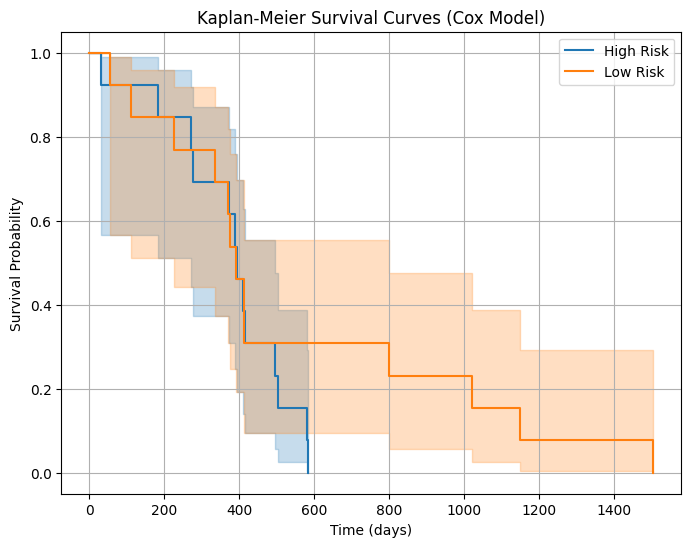

In [88]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

plt.figure(figsize=(8,6))

# High risk
kmf_high.fit(
    T_test_arr[high_risk],
    event_observed=E_test_arr[high_risk],
    label="High Risk"
)
kmf_high.plot_survival_function()

# Low risk
kmf_low.fit(
    T_test_arr[low_risk],
    event_observed=E_test_arr[low_risk],
    label="Low Risk"
)
kmf_low.plot_survival_function()

plt.title("Kaplan-Meier Survival Curves (Cox Model)")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.grid()

plt.show()

In [89]:
from lifelines.statistics import logrank_test

results = logrank_test(
    T_test_arr[high_risk],
    T_test_arr[low_risk],
    event_observed_A=E_test_arr[high_risk],
    event_observed_B=E_test_arr[low_risk]
)

print("Log-rank p-value:", results.p_value)

Log-rank p-value: 0.2833980120847294


<Figure size 800x600 with 0 Axes>

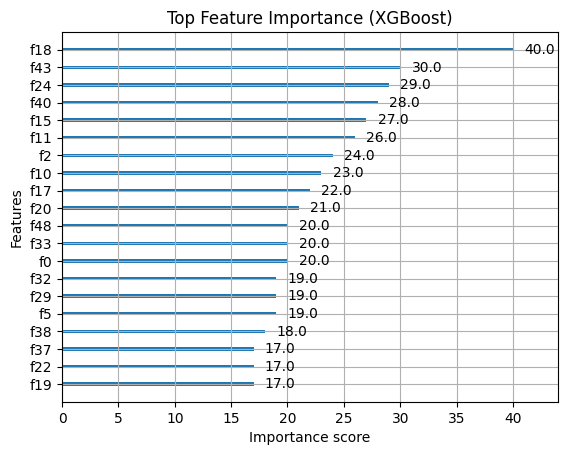

In [95]:
import matplotlib.pyplot as plt
import xgboost as xgb

plt.figure(figsize=(8,6))
xgb.plot_importance(xgb_model, max_num_features=20)
plt.title("Top Feature Importance (XGBoost)")
plt.show()

In [96]:
cox_importance = cox.summary.copy()

cox_importance["abs_coef"] = cox_importance["coef"].abs()

top_features = cox_importance.sort_values("abs_coef", ascending=False).head(20)

print(top_features[["coef", "p"]])

               coef         p
covariate                    
18        -0.398706  0.000732
20        -0.283701  0.023928
48         0.273348  0.019274
32        -0.271494  0.032890
43        -0.268087  0.033016
17        -0.231055  0.056620
34         0.229451  0.079843
40         0.222735  0.061765
30         0.208140  0.074938
14         0.193482  0.120388
46         0.192042  0.099995
16        -0.174041  0.186956
10        -0.174036  0.117468
15         0.171552  0.162604
19         0.171125  0.192857
3         -0.169160  0.146978
13         0.161878  0.147929
24        -0.161278  0.203013
6          0.146718  0.167686
39         0.137639  0.253586


In [97]:
import os
import joblib
import pickle
import torch

os.makedirs("saved_models", exist_ok=True)


final_df.to_csv("saved_models/final_dataset.csv", index=False)



np.save("saved_models/X_train.npy", X_train)
np.save("saved_models/X_test.npy", X_test)

np.save("saved_models/T_train.npy", T_train)
np.save("saved_models/T_test.npy", T_test)

np.save("saved_models/E_train.npy", E_train)
np.save("saved_models/E_test.npy", E_test)


joblib.dump(imputer, "saved_models/imputer.pkl")
joblib.dump(scaler, "saved_models/scaler.pkl")
joblib.dump(selector, "saved_models/variance_selector.pkl")


with open("saved_models/cox_model.pkl", "wb") as f:
    pickle.dump(cox, f)


xgb_model.save_model("saved_models/xgb_model.json")


torch.save(model.state_dict(), "saved_models/deepsurv_model.pth")



try:
    import json
    with open("saved_models/final_features.json", "w") as f:
        json.dump(final_features, f)
except:
    print("Feature names not available, skipped")

print(" Everything saved successfully!")

 Everything saved successfully!


In [98]:
import shutil
shutil.make_archive("saved_models", 'zip', "saved_models")

'/kaggle/working/saved_models.zip'